<a href="https://colab.research.google.com/github/doli-b/3d-webinar/blob/main/Insurance_Data_Cleaning_EDA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [173]:
# ==========================================================
# Insurance Dataset Cleaning and Exploratory Data Analysis
# ==========================================================

# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [174]:
# Load Dataset

df = pd.read_csv("insurance.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [175]:
# Display first five rows

print("First Five Rows")
display(df.head())

First Five Rows


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [176]:
# Display dataset shape

print("Dataset Shape")

print(df.shape)

Dataset Shape
(1338, 7)


In [177]:
# Display column names

print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [178]:
# Display data types

print(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [179]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [180]:
# Creating missing values only for demonstration

df.loc[10:15, "bmi"] = np.nan

df.loc[25:30, "charges"] = np.nan

In [181]:
# Missing Values Count

missing_count = df.isnull().sum()

print(missing_count)

age         0
sex         0
bmi         6
children    0
smoker      0
region      0
charges     6
dtype: int64


In [182]:
# Missing Percentage

missing_percentage = (df.isnull().sum()/df.shape[0])*100

print(missing_percentage)

age         0.00000
sex         0.00000
bmi         0.44843
children    0.00000
smoker      0.00000
region      0.00000
charges     0.44843
dtype: float64


In [183]:
# Combine both into one table

missing_table = pd.DataFrame({

    "Missing Values": missing_count,

    "Missing Percentage": missing_percentage

})

missing_table

,Missing Values,Missing Percentage
age,0,0.00000
sex,0,0.00000
bmi,6,0.44843
children,0,0.00000
smoker,0,0.00000
region,0,0.00000
charges,6,0.44843


In [184]:
more_than_20 = missing_table[

    missing_table["Missing Percentage"] > 20

]

print(more_than_20)

Empty DataFrame
Columns: [Missing Values, Missing Percentage]
Index: []


In [185]:
# Fill numerical columns with median

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:

    if df[col].isnull().sum()>0:

        df[col] = df[col].fillna(df[col].median())

In [186]:
# Verify Missing Values

df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [187]:
# ==========================================
# Duplicate Detection
# ==========================================

# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 1


In [188]:
# Remove duplicate rows

rows_before = df.shape[0]

df = df.drop_duplicates()

rows_after = df.shape[0]

rows_removed = rows_before - rows_after

print("Rows Before Removing Duplicates :", rows_before)
print("Rows After Removing Duplicates  :", rows_after)
print("Total Rows Removed              :", rows_removed)

Rows Before Removing Duplicates : 1338
Rows After Removing Duplicates  : 1337
Total Rows Removed              : 1


In [189]:
# Check null percentage after removing duplicates

new_null_percentage = (df.isnull().sum()/df.shape[0])*100

comparison = pd.DataFrame({

    "Before": missing_percentage,

    "After": new_null_percentage

})

comparison

,Before,After
age,0.00000,0.0
sex,0.00000,0.0
bmi,0.44843,0.0
children,0.00000,0.0
smoker,0.00000,0.0
region,0.00000,0.0
charges,0.44843,0.0


In [190]:
# Convert numeric column to object (Demonstration)

df["children"] = df["children"].astype(str)

print(df.dtypes)

age           int64
sex          object
bmi         float64
children     object
smoker       object
region       object
charges     float64
dtype: object


In [191]:
# Convert object back to numeric

df["children"] = pd.to_numeric(

    df["children"],

    errors="coerce"

)

print(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [192]:
categorical_columns = ["sex","smoker","region"]

for col in categorical_columns:

    df[col] = df[col].astype("category")

In [193]:
print(df.dtypes)

age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object


In [194]:
# Memory before optimization

df_original = pd.read_csv("insurance.csv")

memory_before = df_original.memory_usage(deep=True).sum()

print("Memory Before:", memory_before, "bytes")

Memory Before: 261302 bytes


In [195]:
# Memory after optimization

memory_after = df.memory_usage(deep=True).sum()

print("Memory After :", memory_after, "bytes")

Memory After : 58322 bytes


In [196]:
print("Memory Saved :", memory_before-memory_after, "bytes")

Memory Saved : 202980 bytes


In [197]:
# Descriptive Statistics

df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.655180,1.095737,13232.902127
std,14.044333,6.081753,1.205571,12074.240452
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.315000,0.000000,4747.052900
50%,39.000000,30.400000,1.000000,9333.014350
75%,51.000000,34.600000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [198]:
# Calculate skewness

numeric_columns = df.select_dtypes(include=np.number).columns

skewness = pd.DataFrame({

    "Skewness":[

        df[col].skew()

        for col in numeric_columns

    ]

},

index=numeric_columns)

skewness

,Skewness
age,0.054781
bmi,0.284187
children,0.937421
charges,1.529137


In [199]:
# Highest Absolute Skewness

highest_skew = skewness["Skewness"].abs().idxmax()

print("Highest Skewed Column :", highest_skew)

print("Skewness Value :", skewness.loc[highest_skew])

Highest Skewed Column : charges
Skewness Value : Skewness    1.529137
Name: charges, dtype: float64


In [200]:
col = "bmi"

Q1 = df[col].quantile(0.25)

Q3 = df[col].quantile(0.75)

IQR = Q3-Q1

lower = Q1-(1.5*IQR)

upper = Q3+(1.5*IQR)

outliers_bmi = df[(df[col]<lower)|(df[col]>upper)]

print("BMI Outliers :", len(outliers_bmi))

BMI Outliers : 9


In [201]:
col = "charges"

Q1 = df[col].quantile(0.25)

Q3 = df[col].quantile(0.75)

IQR = Q3-Q1

lower = Q1-(1.5*IQR)

upper = Q3+(1.5*IQR)

outliers_charges = df[(df[col]<lower)|(df[col]>upper)]

print("Charges Outliers :", len(outliers_charges))

Charges Outliers : 139


**visualisation**

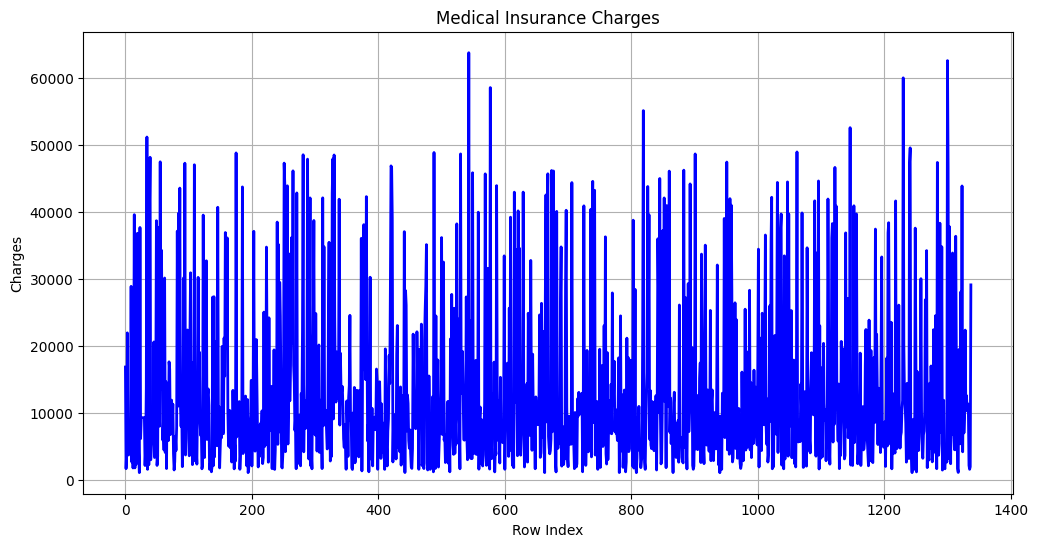

In [202]:
# ==========================================
# Line Plot
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(df.index,
         df["charges"],
         color="blue",
         linewidth=2)

plt.title("Medical Insurance Charges")

plt.xlabel("Row Index")

plt.ylabel("Charges")

plt.grid(True)

plt.show()



In [203]:
plt.savefig('plot.png',dpi=150,bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

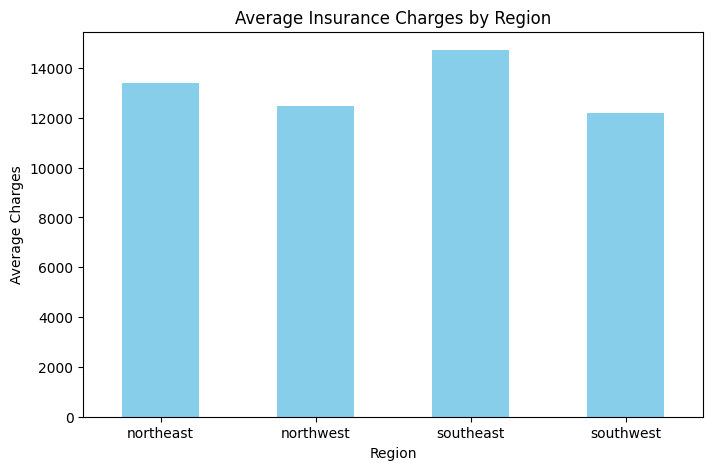

In [204]:
# ==========================================
# Mean Charges by Region
# ==========================================

region_mean = df.groupby("region")["charges"].mean()

plt.figure(figsize=(8,5))

region_mean.plot(kind="bar",
                 color="skyblue")

plt.title("Average Insurance Charges by Region")

plt.xlabel("Region")

plt.ylabel("Average Charges")

plt.xticks(rotation=0)

plt.show()



In [205]:
plt.savefig('bar_chart.png',dpi=150,bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [206]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


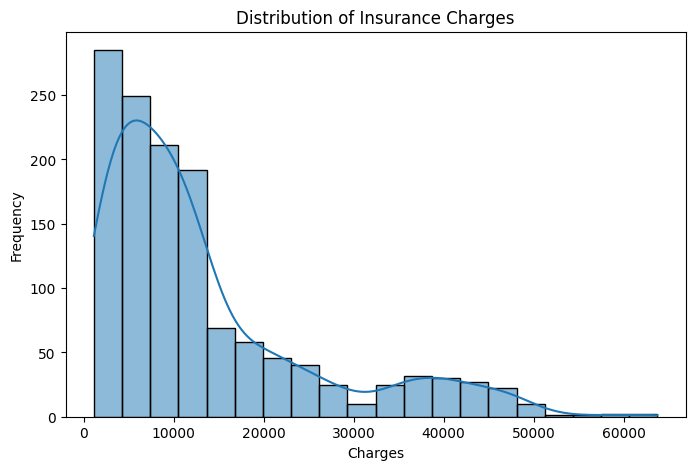

In [207]:
# ==========================================
# Histogram
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(df["charges"],
             bins=20,
             kde=True)

plt.title("Distribution of Insurance Charges")

plt.xlabel("Charges")

plt.ylabel("Frequency")

plt.show()


In [208]:
plt.savefig('hist_chart.png',dpi=150,bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

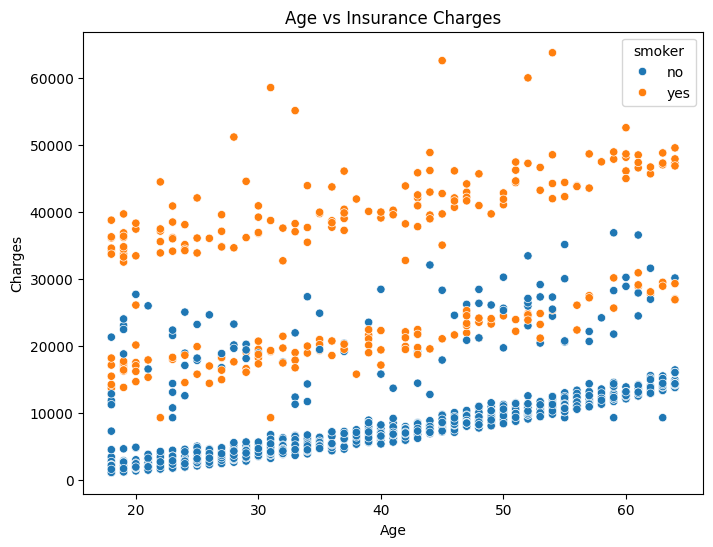

In [209]:
# ==========================================
# Scatter Plot
# ==========================================

plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x="age",
                y="charges",
                hue="smoker")

plt.title("Age vs Insurance Charges")

plt.xlabel("Age")

plt.ylabel("Charges")

plt.show()



In [210]:
plt.savefig('scatter.png',dpi=150,bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

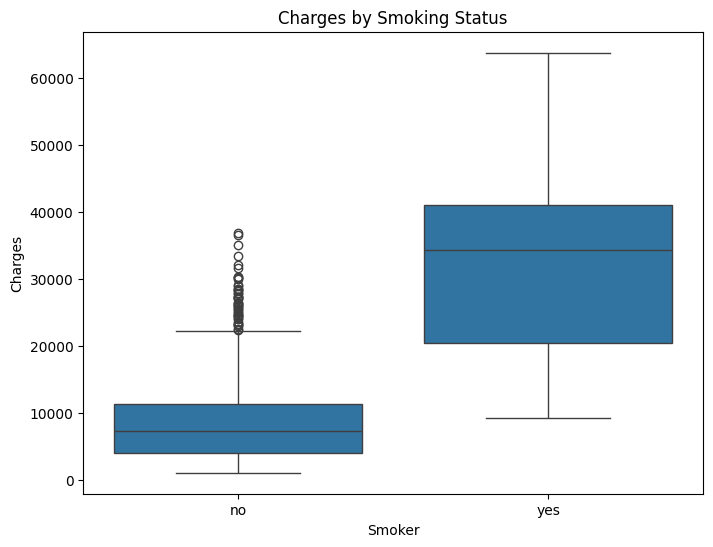

In [211]:
# ==========================================
# Box Plot
# ==========================================

plt.figure(figsize=(8,6))

sns.boxplot(data=df,
            x="smoker",
            y="charges")

plt.title("Charges by Smoking Status")

plt.xlabel("Smoker")

plt.ylabel("Charges")

plt.show()


In [212]:
plt.savefig('box_plot.png',dpi=150,bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [213]:
# ==========================================
# Pearson Correlation
# ==========================================

pearson_corr = df.corr(numeric_only=True)

print(pearson_corr)

               age       bmi  children   charges
age       1.000000  0.109392  0.041536  0.300644
bmi       0.109392  1.000000  0.014623  0.193188
children  0.041536  0.014623  1.000000  0.067367
charges   0.300644  0.193188  0.067367  1.000000


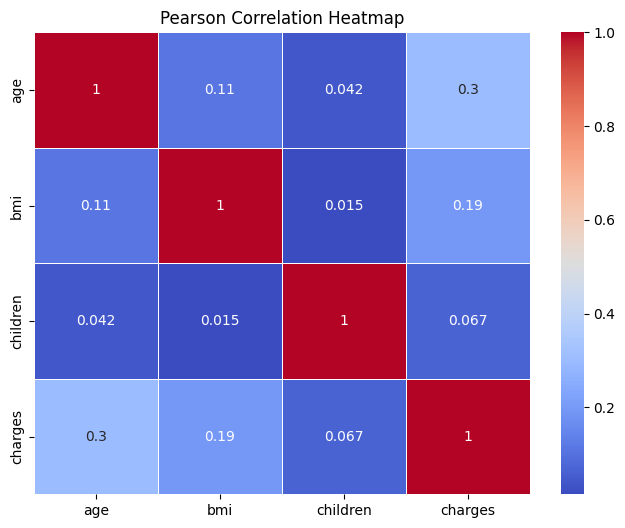

In [214]:
# ==========================================
# Heatmap
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")

plt.show()



In [215]:
plt.savefig('heat_map.png',dpi=150,bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [216]:
# ==========================================
# Mean vs Median
# ==========================================

numeric_cols = df.select_dtypes(include=np.number).columns

skew_values = {}

for col in numeric_cols:
    skew_values[col] = abs(df[col].skew())

top_two = sorted(
    skew_values,
    key=skew_values.get,
    reverse=True
)[:2]

print("Top Two Skewed Columns")

print(top_two)

Top Two Skewed Columns
['charges', 'children']


In [217]:
comparison = []

for col in top_two:

    comparison.append({

        "Column": col,

        "Mean": df[col].mean(),

        "Median": df[col].median(),

        "Skewness": df[col].skew()

    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,Column,Mean,Median,Skewness
0,charges,13232.902127,9333.01435,1.529137
1,children,1.095737,1.00000,0.937421


In [218]:
df[top_two].isnull().sum()

,0
charges,0
children,0


In [219]:
# ==========================================
# Spearman Correlation
# ==========================================

spearman_corr = df.corr(method="spearman",
                        numeric_only=True)

print(spearman_corr)

               age       bmi  children   charges
age       1.000000  0.107760  0.055813  0.535046
bmi       0.107760  1.000000  0.017602  0.114573
children  0.055813  0.017602  1.000000  0.131373
charges   0.535046  0.114573  0.131373  1.000000


In [220]:
difference = abs(
    spearman_corr - pearson_corr
)

difference

,age,bmi,children,charges
age,0.000000,0.001631,0.014277,0.234403
bmi,0.001631,0.000000,0.002979,0.078615
children,0.014277,0.002979,0.000000,0.064006
charges,0.234403,0.078615,0.064006,0.000000


In [221]:
pairs = []

columns = difference.columns

for i in range(len(columns)):
    for j in range(i+1,len(columns)):
        pairs.append([

            columns[i],

            columns[j],

            difference.iloc[i,j],

            pearson_corr.iloc[i,j],

            spearman_corr.iloc[i,j]

        ])

difference_table = pd.DataFrame(

pairs,

columns=[

"Column 1",

"Column 2",

"|Difference|",

"Pearson",

"Spearman"

])

difference_table = difference_table.sort_values(

"|Difference|",

ascending=False)

difference_table.head(3)

,Column 1,Column 2,|Difference|,Pearson,Spearman
2,age,charges,0.234403,0.300644,0.535046
4,bmi,charges,0.078615,0.193188,0.114573
5,children,charges,0.064006,0.067367,0.131373


In [222]:
# ==========================================
# Grouped Aggregation
# ==========================================

group_result = df.groupby("region")["charges"].agg(
    ["mean", "std", "count"]
)

print(group_result)

                   mean           std  count
region                                      
northeast  13390.585687  11257.923342    324
northwest  12462.020487  11062.740890    324
southeast  14722.586934  13973.916683    364
southwest  12175.766463  11392.235954    325


In [223]:
highest_mean_group = group_result["mean"].idxmax()
highest_mean_value = group_result["mean"].max()

print("Highest Mean Group :", highest_mean_group)
print("Highest Mean :", highest_mean_value)

Highest Mean Group : southeast
Highest Mean : 14722.586933626373


In [224]:
highest_std_group = group_result["std"].idxmax()
highest_std_value = group_result["std"].max()

print("Highest Standard Deviation Group :", highest_std_group)
print("Standard Deviation :", highest_std_value)

Highest Standard Deviation Group : southeast
Standard Deviation : 13973.916683438725


In [225]:
highest_mean = group_result["mean"].max()

lowest_mean = group_result["mean"].min()

ratio = highest_mean / lowest_mean

print("Mean Ratio =", ratio)

Mean Ratio = 1.2091712648187194


In [226]:
print("Final Missing Values")

print(df.isnull().sum())

Final Missing Values
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [227]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1337 non-null   int64   
 1   sex       1337 non-null   category
 2   bmi       1337 non-null   float64 
 3   children  1337 non-null   int64   
 4   smoker    1337 non-null   category
 5   region    1337 non-null   category
 6   charges   1337 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 56.6 KB
None


In [228]:
df.to_csv(
    "cleaned_data.csv",
    index=False
)

print("cleaned_data.csv saved successfully.")

cleaned_data.csv saved successfully.


In [229]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
